In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [110]:

# Load the data
df = pd.read_csv("C:\\Users\\rautk\\Downloads\\USvideos.csv")

if df is not None:
    # Display basic info
    print("\n📋 First 3 rows:")
    print(df.head(3))
    
    print("\n🔍 Column names:")
    print(df.columns.tolist())
    
    print("\n📊 Dataset info:")
    print(df.info())
    
    print("\n🧮 Basic statistics:")
    print(df[['views', 'likes', 'dislikes', 'comment_count']].describe())
    
    # DATA CLEANING
    print("\n" + "="*50)
    print("DATA CLEANING")
    print("="*50)
    
    # Check for missing values
    print("Missing values:")
    print(df.isnull().sum())
    
    # Remove duplicates
    initial_count = len(df)
    df = df.drop_duplicates()
    final_count = len(df)
    print(f"Removed {initial_count - final_count} duplicate rows")
    
    # Convert date columns
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
    df['publish_time'] = pd.to_datetime(df['publish_time']).dt.tz_localize(None)


📋 First 3 rows:
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   

                                               title    channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE     CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...  LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...     Rudy Mancuso   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   

                                                tags    views   likes  \
0                                    SHANtell martin   748374   57527   
1  last week tonight trump presidency|"last week ...  2418783   97185   
2  racist superman|"rudy"|"mancuso"|"king"|"bach"...  3191434  146033   

   dislikes  comment_count                                  thumbnail_link  \
0      2966  

Average views: 2,360,678
Average likes: 74,272
Average dislikes: 3,712
Average comments: 8,449


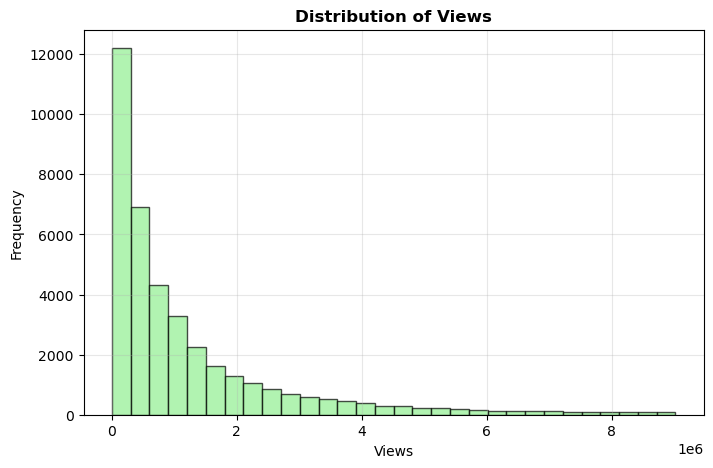

In [111]:
    print(f"Average views: {df['views'].mean():,.0f}")
    print(f"Average likes: {df['likes'].mean():,.0f}")
    if 'dislikes' in df.columns:
        print(f"Average dislikes: {df['dislikes'].mean():,.0f}")
    if 'comment_count' in df.columns:
        print(f"Average comments: {df['comment_count'].mean():,.0f}")
    
    # FIGURE 4: Views Distribution
    plt.figure(figsize=(8, 5))
    reasonable_views = df[df['views'] <= df['views'].quantile(0.95)]['views']
    plt.hist(reasonable_views, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.title('Distribution of Views', fontsize=12, fontweight='bold')
    plt.xlabel('Views', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

📊 Dataset after cleaning: 40901 videos

📊 CORRELATION ANALYSIS:
                  views     likes  dislikes  comment_count
views          1.000000  0.849179  0.472216       0.617657
likes          0.849179  1.000000  0.447188       0.803088
dislikes       0.472216  0.447188  1.000000       0.700192
comment_count  0.617657  0.803088  0.700192       1.000000

🔍 CORRELATION WITH VIEWS:
  likes          : 0.8492
  comment_count  : 0.6177
  dislikes       : 0.4722


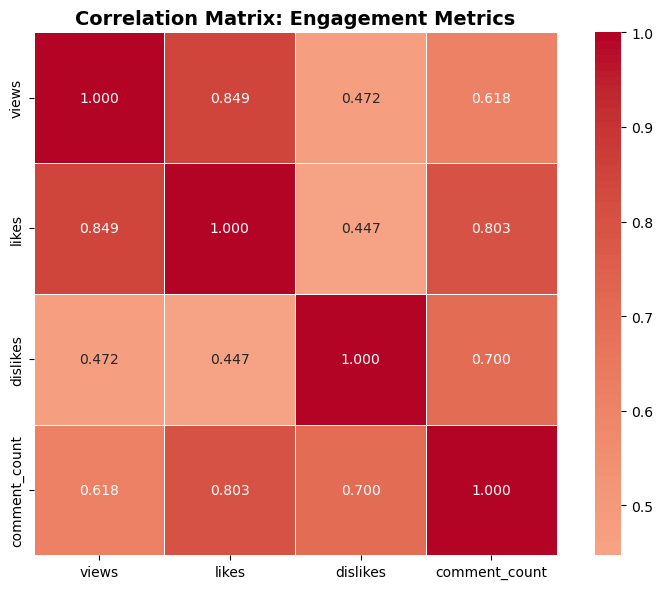

In [112]:
# CORRELATION ANALYSIS 
# Data cleaning
df_clean = df.dropna(subset=['views', 'likes', 'dislikes', 'comment_count'])

# Remove invalid values
df_clean = df_clean[
    (df_clean['views'] > 0) & 
    (df_clean['likes'] >= 0) & 
    (df_clean['dislikes'] >= 0) & 
    (df_clean['comment_count'] >= 0)
]

print(f"📊 Dataset after cleaning: {df_clean.shape[0]} videos")

# CORRELATION ANALYSIS 
print("\n📊 CORRELATION ANALYSIS:")
print("=" * 40)
correlation_matrix = df_clean[['views', 'likes', 'dislikes', 'comment_count']].corr()
print(correlation_matrix)

# Additional correlation insights
print("\n🔍 CORRELATION WITH VIEWS:")
views_correlations = correlation_matrix['views'].sort_values(ascending=False)
for metric, corr in views_correlations.items():
    if metric != 'views':
        print(f"  {metric:15}: {corr:.4f}")

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix: Engagement Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [113]:
# Channel-level metrics
channel_stats = df.groupby('channel_title').agg({
    'video_id': 'count',
    'views': 'sum',
    'likes': 'sum',
    'dislikes': 'sum',
    'comment_count': 'sum'
}).round(2)

# Rename columns
channel_stats.columns = [
    'video_count', 
    'total_views', 
    'total_likes', 
    'total_dislikes',
    'total_comments'
]
print("\nTop 10 Channels by Video Count:")
print(top_channels_by_video_count)


Top 10 Channels by Video Count:
                                        video_count  total_views  total_likes  \
channel_title                                                                   
ESPN                                            202    105181219       934218   
The Tonight Show Starring Jimmy Fallon          197    271426383      5981334   
Netflix                                         193    185818315      4211072   
TheEllenShow                                    192    253137213      6015252   
Vox                                             192    122200130      3260162   
The Late Show with Stephen Colbert              187    123675646      1511686   
Jimmy Kimmel Live                               185    280551472      4758021   
Late Night with Seth Meyers                     183    181602246      2098813   
Screen Junkies                                  182    319075554      8836325   
NBA                                             181     72404568       87889

TIME-TO-TREND ANALYSIS
Average time to trend: 151.49 hours
Median time to trend: 114.74 hours
Minimum time to trend: 0.00 hours
Maximum time to trend: 8096.65 hours


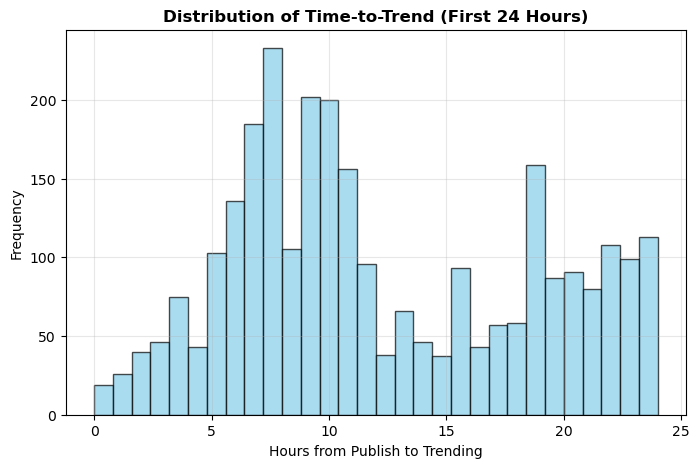

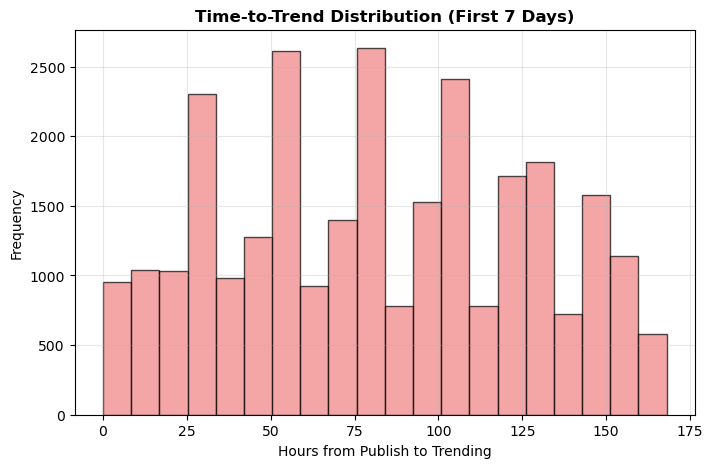

In [114]:
# TIME-TO-TREND ANALYSIS
print("TIME-TO-TREND ANALYSIS")
print("="*40)

if 'trending_date' in df.columns and 'publish_time' in df.columns:
    # Calculate time to trend in hours
    df['time_to_trend_hours'] = (df['trending_date'] - df['publish_time']).dt.total_seconds() / 3600
    
    # Remove invalid times (negative or extremely large)
    valid_times = df[(df['time_to_trend_hours'] >= 0) & (df['time_to_trend_hours'] <= 8760)]  # Max 1 year
    
    print(f"Average time to trend: {valid_times['time_to_trend_hours'].mean():.2f} hours")
    print(f"Median time to trend: {valid_times['time_to_trend_hours'].median():.2f} hours")
    print(f"Minimum time to trend: {valid_times['time_to_trend_hours'].min():.2f} hours")
    print(f"Maximum time to trend: {valid_times['time_to_trend_hours'].max():.2f} hours")
    
    # FIGURE 1: Time-to-trend distribution 
    plt.figure(figsize=(8, 5))
    reasonable_times = valid_times[valid_times['time_to_trend_hours'] <= 24]['time_to_trend_hours']
    plt.hist(reasonable_times, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution of Time-to-Trend (First 24 Hours)', fontsize=12, fontweight='bold')
    plt.xlabel('Hours from Publish to Trending', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # FIGURE 2: Time-to-trend distribution (First 7 Days)
    plt.figure(figsize=(8, 5))
    week_times = valid_times[valid_times['time_to_trend_hours'] <= 168]['time_to_trend_hours']
    plt.hist(week_times, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    plt.title('Time-to-Trend Distribution (First 7 Days)', fontsize=12, fontweight='bold')
    plt.xlabel('Hours from Publish to Trending', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

Average engagement rate: 4.0484%


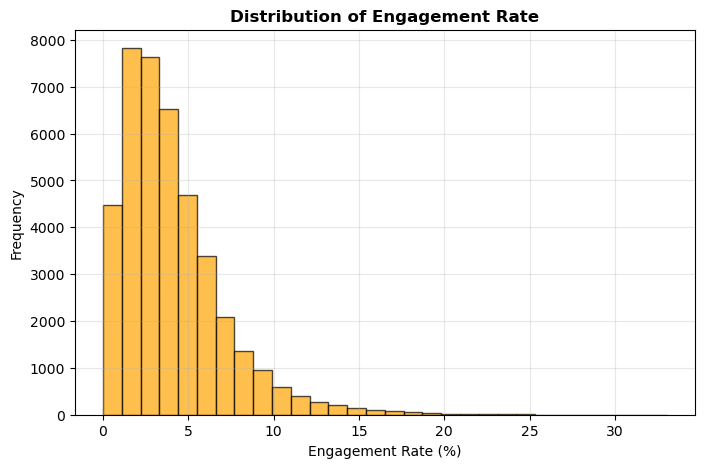

In [116]:
# ENGAGEMENT ANALYSIS
#engagement_rate= (likes+dislikes+comment_count)/views
if 'views' in df.columns and 'likes' in df.columns:
    # Calculate engagement metrics
    if all(col in df.columns for col in ['likes', 'dislikes', 'comment_count']):
        df['total_engagement'] = df['likes'] + df['dislikes'] + df['comment_count']
        df['engagement_rate'] = (df['total_engagement'] / df['views']) * 100
        df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes']).replace(0, 1)
        
        print(f"Average engagement rate: {df['engagement_rate'].mean():.4f}%")
       #print(f"Average like ratio: {df['like_ratio'].mean():.3f}")
        
        # FIGURE 3: Engagement Rate Distribution
        plt.figure(figsize=(8, 5))
        engagement_clean = df[df['engagement_rate'] <= 50]['engagement_rate']  # Remove outliers
        plt.hist(engagement_clean, bins=30, alpha=0.7, color='orange', edgecolor='black')
        plt.title('Distribution of Engagement Rate', fontsize=12, fontweight='bold')
        plt.xlabel('Engagement Rate (%)', fontsize=10)
        plt.ylabel('Frequency', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.show()

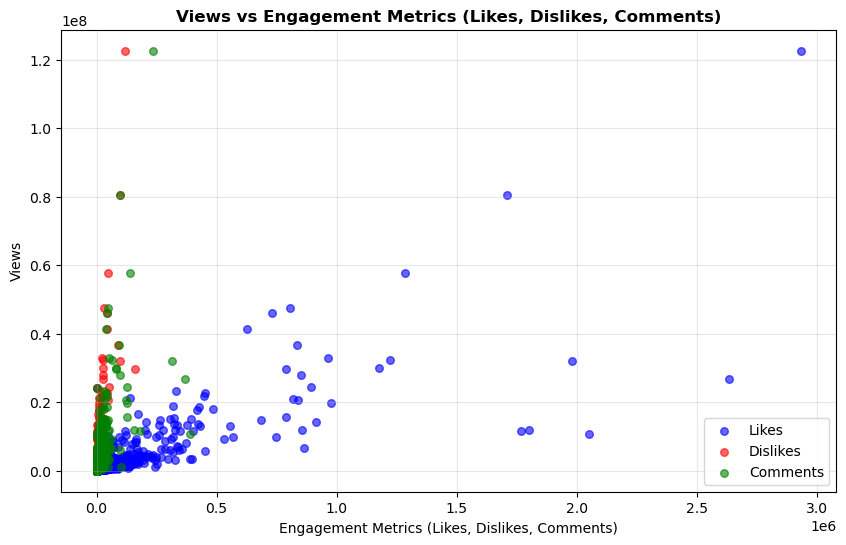

In [117]:
# FIGURE 5: Views vs Likes, Dislikes and comment_count Scatter Plot
plt.figure(figsize=(10, 6))
sample_df = df_clean.sample(min(1000, len(df_clean)))

# Plot all three relationships in one scatter plot
plt.scatter(sample_df['likes'], sample_df['views'], alpha=0.6, color='blue', label='Likes', s=30)
plt.scatter(sample_df['dislikes'], sample_df['views'], alpha=0.6, color='red', label='Dislikes', s=30)
plt.scatter(sample_df['comment_count'], sample_df['views'], alpha=0.6, color='green', label='Comments', s=30)

plt.title('Views vs Engagement Metrics (Likes, Dislikes, Comments)', fontsize=12, fontweight='bold')
plt.xlabel('Engagement Metrics (Likes, Dislikes, Comments)', fontsize=10)
plt.ylabel('Views', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Average title length: 48.6 characters
Median title length: 46.0 characters
Minimum title length: 3 characters
Maximum title length: 100 characters


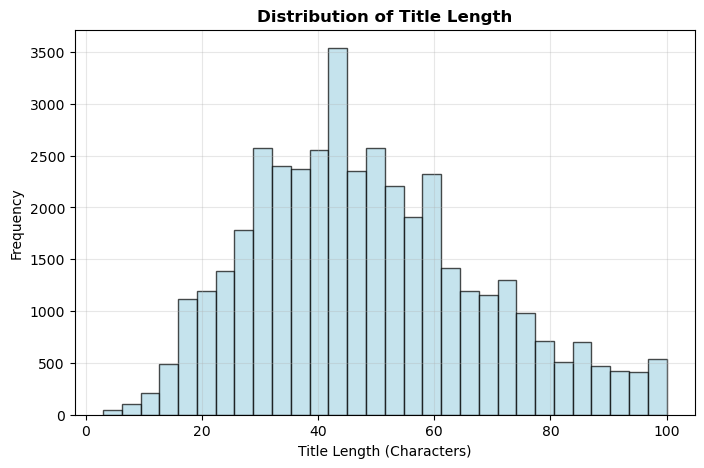

In [118]:
# TITLE ANALYSIS
if 'title' in df.columns:
    # Calculate title length
    df['title_length'] = df['title'].str.len()
    
    print(f"Average title length: {df['title_length'].mean():.1f} characters")
    print(f"Median title length: {df['title_length'].median():.1f} characters")
    print(f"Minimum title length: {df['title_length'].min()} characters")
    print(f"Maximum title length: {df['title_length'].max()} characters")
    
    # FIGURE 1: Title Length Distribution
    plt.figure(figsize=(8, 5))
    plt.hist(df['title_length'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    plt.title('Distribution of Title Length', fontsize=12, fontweight='bold')
    plt.xlabel('Title Length (Characters)', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

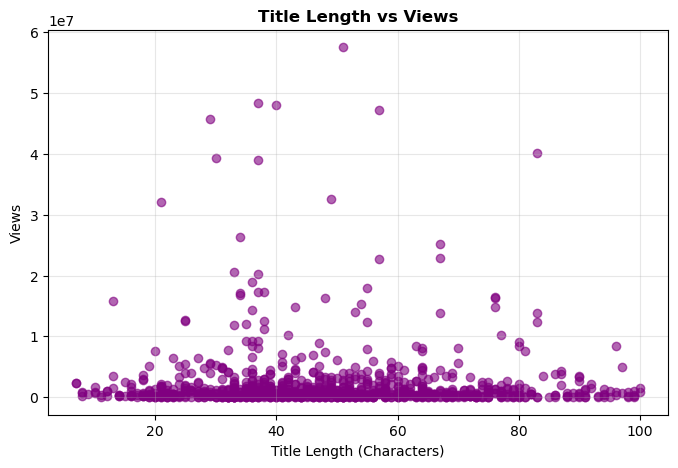

In [119]:
    # FIGURE 2: Title Length vs Views
    plt.figure(figsize=(8, 5))
    sample_df = df.sample(min(1000, len(df)))
    plt.scatter(sample_df['title_length'], sample_df['views'], alpha=0.6, color='purple')
    plt.title('Title Length vs Views', fontsize=12, fontweight='bold')
    plt.xlabel('Title Length (Characters)', fontsize=10)
    plt.ylabel('Views', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

Top 20 Most Used Words in Titles:
  official: 3985 times
  video: 2861 times
  trailer: 1998 times
  how: 1862 times
  what: 1106 times
  new: 1005 times
  makeup: 876 times
  audio: 870 times
  music: 836 times
  live: 790 times
  first: 751 times
  why: 702 times
  day: 696 times
  challenge: 670 times
  out: 632 times
  full: 621 times
  game: 604 times
  black: 593 times
  star: 572 times
  world: 571 times


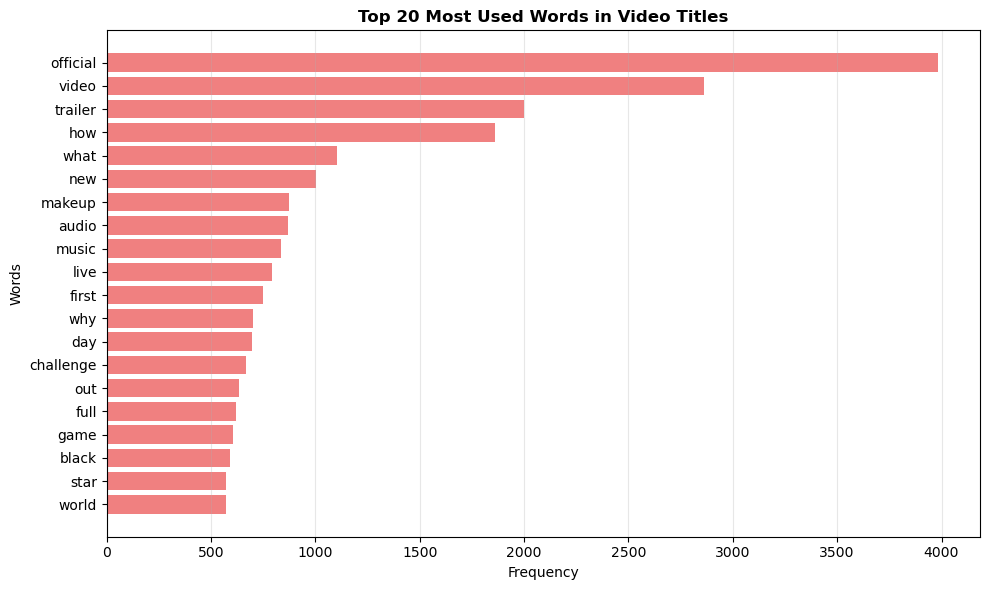

In [120]:
# MOST USED WORDS IN TITLES
if 'title' in df.columns:
    import re
    from collections import Counter
    
    # Combine all titles and clean them
    all_titles = ' '.join(df['title'].astype(str))
    
    # Clean the text: remove punctuation, convert to lowercase
    words = re.findall(r'\b[a-zA-Z]{3,}\b', all_titles.lower())
    
    # Remove common stop words
    stop_words = {'the', 'and', 'to', 'of', 'a', 'in', 'for', 'is', 'on', 'that', 'by', 
                 'this', 'with', 'i', 'you', 'it', 'not', 'or', 'be', 'are', 'from', 
                 'at', 'as', 'your', 'have', 'more', 'an', 'was', 'we', 'will', 'can'}
    
    filtered_words = [word for word in words if word not in stop_words]
    
    # Get most common words
    word_counts = Counter(filtered_words)
    top_20_words = word_counts.most_common(20)
    
    print("Top 20 Most Used Words in Titles:")
    for word, count in top_20_words:
        print(f"  {word}: {count} times")
    
    # FIGURE 3: Top 20 Most Used Words
    plt.figure(figsize=(10, 6))
    words, counts = zip(*top_20_words)
    plt.barh(words, counts, color='lightcoral')
    plt.title('Top 20 Most Used Words in Video Titles', fontsize=12, fontweight='bold')
    plt.xlabel('Frequency', fontsize=10)
    plt.ylabel('Words', fontsize=10)
    plt.gca().invert_yaxis()  # Highest frequency at top
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

In [121]:
# The key is: we're counting by THUMBNAIL URL
print("EXPLANATION: How thumbnail counting works:")
print("="*50)

if 'thumbnail_link' in df.columns:
    # We're counting occurrences of each unique thumbnail URL
    thumbnail_usage = df['thumbnail_link'].value_counts()
    
    print(f"Total unique thumbnail URLs: {len(thumbnail_usage)}")
    print(f"Total videos in dataset: {len(df)}")
    print(f"Most reused thumbnail URL appears: {thumbnail_usage.max()} times")
    print(f"Thumbnail URLs used more than once: {len(thumbnail_usage[thumbnail_usage > 1])}")
    
    # Show some examples of duplicate thumbnail URLs
    duplicate_examples = thumbnail_usage[thumbnail_usage > 1].head(5)
    print(f"\nExample duplicate thumbnail URLs:")
    for url, count in duplicate_examples.items():
        print(f"  URL: {url[:80]}...")  # Show first 80 characters
        print(f"  Used in {count} videos")
        print()

EXPLANATION: How thumbnail counting works:
Total unique thumbnail URLs: 6352
Total videos in dataset: 40901
Most reused thumbnail URL appears: 29 times
Thumbnail URLs used more than once: 5643

Example duplicate thumbnail URLs:
  URL: https://i.ytimg.com/vi/8h--kFui1JA/default.jpg...
  Used in 29 videos

  URL: https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg...
  Used in 29 videos

  URL: https://i.ytimg.com/vi/6S9c5nnDd_s/default.jpg...
  Used in 28 videos

  URL: https://i.ytimg.com/vi/ulNswX3If6U/default.jpg...
  Used in 28 videos

  URL: https://i.ytimg.com/vi/QBL8IRJ5yHU/default.jpg...
  Used in 28 videos



Top 20 Most Common Tags:
funny        3597
comedy       2927
how to       1602
music        1298
Pop          1278
2018         1271
humor        1184
food         1159
science      1111
review       1004
makeup        989
news          987
celebrity     930
vlog          926
video         888
tutorial      864
live          859
comedian      859
interview     845
cooking       802
Name: count, dtype: int64


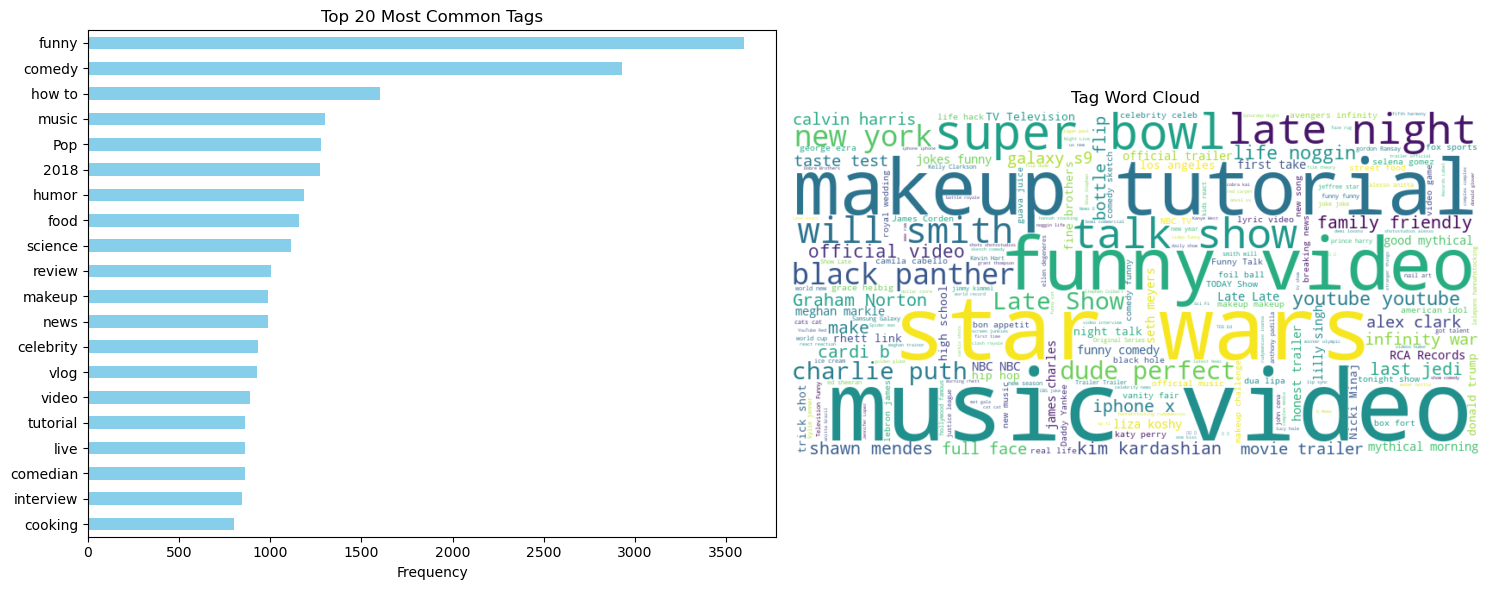


CO-OCCURRENCE ANALYSIS:
Top co-occurring tag pairs:
  comedy + funny: 1967 times
  funny + humor: 889 times
  comedy + humor: 755 times
  comedian + funny: 733 times
  funny + late night: 605 times
  comedian + comedy: 583 times
  funny video + jokes: 558 times
  humor + jokes: 557 times
  celebrities + humor: 556 times
  celebrities + jokes: 552 times


In [122]:
# Clean the data to remove empty tags
def clean_tags(tag_string):
    if pd.isna(tag_string):
        return []
    tags = [tag.strip().strip('"') for tag in tag_string.split('|')]
    return [tag for tag in tags if tag not in ['', '[none]', 'none']]

# Apply cleaning to the dataframe
df['cleaned_tags'] = df['tags'].apply(clean_tags)

# Create a string version for analysis (with | separator)
df['cleaned_tags_str'] = df['cleaned_tags'].apply(lambda x: '|'.join(x) if x else '')

# Basic tag analysis with cleaned data
all_tags = '|'.join(df['cleaned_tags_str'][df['cleaned_tags_str'] != '']).split('|')
tag_counts = pd.Series(all_tags).value_counts().head(20)

print("Top 20 Most Common Tags:")
print(tag_counts)

# Set up plotting style
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Horizontal bar plot
tag_counts.sort_values().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 20 Most Common Tags')
axes[0].set_xlabel('Frequency')

# 2. Word cloud installation
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_tags))
    axes[1].imshow(wordcloud, interpolation='bilinear')
    axes[1].set_title('Tag Word Cloud')
    axes[1].axis('off')
except ImportError:
    axes[1].text(0.5, 0.5, 'Install wordcloud: pip install wordcloud', 
                   ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Word Cloud (install wordcloud package)')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

# Co-occurrence analysis with cleaned data
def analyze_tag_cooccurrence(df, top_n=10):
    """Analyze which tags frequently appear together"""
    cooccurrence = Counter()
    
    for tags_list in df['cleaned_tags']:
        if len(tags_list) > 1:
            for pair in combinations(sorted(tags_list), 2):
                cooccurrence[pair] += 1
    
    # Get top co-occurring pairs
    top_pairs = cooccurrence.most_common(top_n)
    
    print("Top co-occurring tag pairs:")
    for (tag1, tag2), count in top_pairs:
        print(f"  {tag1} + {tag2}: {count} times")
    
    return cooccurrence

# Run co-occurrence analysis
print("\n" + "="*50)
print("CO-OCCURRENCE ANALYSIS:")
print("="*50)
tag_pairs = analyze_tag_cooccurrence(df)

📊 After cleaning: 40949 videos
🎯 Viral threshold: 1,823,157 views
📊 Class distribution:
is_viral
0    30711
1    10238
Name: count, dtype: int64
   Viral videos: 25.0%
🎯 Using features: ['likes', 'dislikes', 'comment_count']

🎯 CLASSIFICATION SETUP:
Features: ['likes', 'dislikes', 'comment_count']
Target: is_viral (1 = Viral, 0 = Non-Viral)
Training set: (32759, 3)
Test set: (8190, 3)

🤖 TRAINING CLASSIFICATION MODELS

🎯 Training Logistic Regression...
   Accuracy: 0.8984
   CV Accuracy: 0.8967 ± 0.0087

🎯 Training Random Forest...
   Accuracy: 0.9455
   CV Accuracy: 0.9401 ± 0.0068

🎯 Training XGBoost...
   Accuracy: 0.9344
   CV Accuracy: 0.9273 ± 0.0067

🎯 Training Neural Network...
   Accuracy: 0.5123
   CV Accuracy: 0.8460 ± 0.0868

CLASSIFICATION RESULTS COMPARISON
              Model  Accuracy     CV Accuracy  Rank
      Random Forest  0.945543 0.9401 ± 0.0068     1
            XGBoost  0.934432 0.9273 ± 0.0067     2
Logistic Regression  0.898413 0.8967 ± 0.0087     3
     Neura

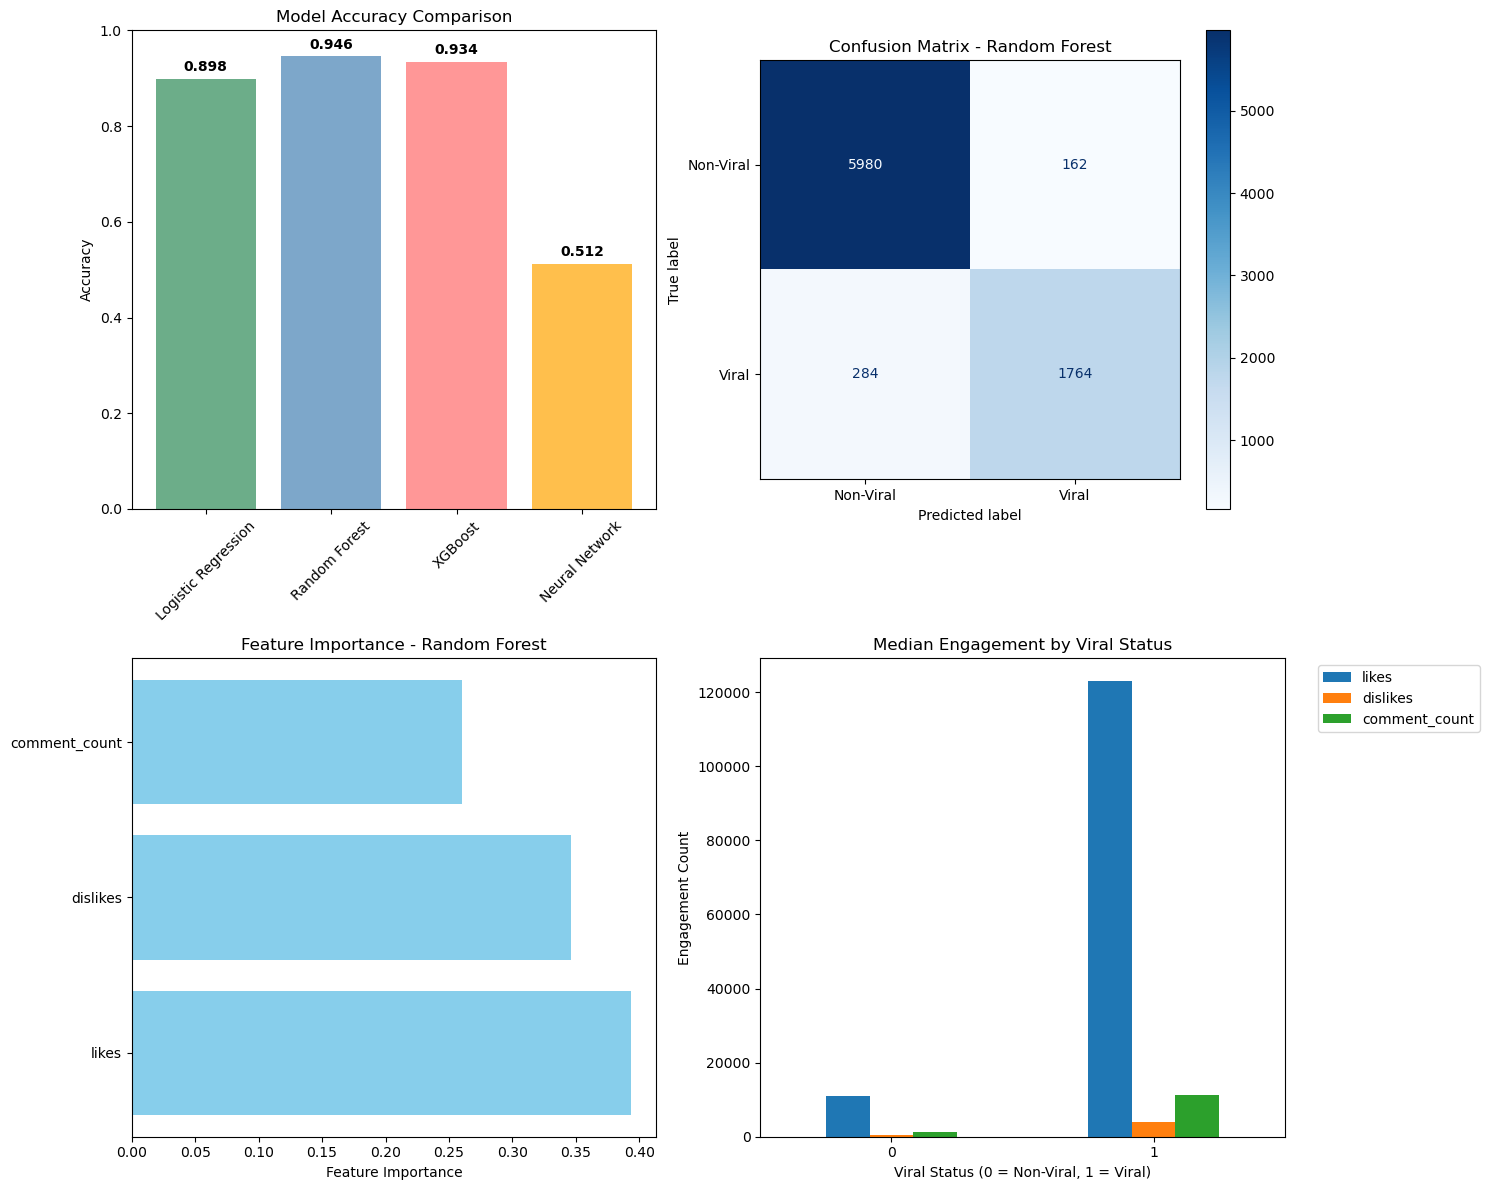

🔍 DETAILED CLASSIFICATION ANALYSIS
🏆 BEST MODEL: Random Forest
   Accuracy: 0.9455
   CV Accuracy: 0.9401 ± 0.0068

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Non-Viral       0.95      0.97      0.96      6142
       Viral       0.92      0.86      0.89      2048

    accuracy                           0.95      8190
   macro avg       0.94      0.92      0.93      8190
weighted avg       0.94      0.95      0.94      8190


📊 ENGAGEMENT PATTERNS BY VIRAL STATUS
Engagement patterns:
             likes           dislikes         comment_count           \
              mean    median     mean  median          mean   median   
is_viral                                                               
0          19575.0   11035.0    882.0   376.0        2520.0   1172.0   
1         238326.0  123056.0  12200.0  3916.0       26225.0  11208.0   

              views             
               mean     median  
is_viral                        
0          5

In [123]:
# CLASSIFICATION: Predicting Viral Videos from Engagement Metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')


# Load the dataset
df = pd.read_csv("C:\\Users\\rautk\\Downloads\\USvideos.csv")

# Remove rows with missing values in key columns
df_clean = df.dropna(subset=['views', 'likes', 'dislikes', 'comment_count'])

# Remove any zeros or negative values that don't make sense
df_clean = df_clean[
    (df_clean['views'] > 0) & 
    (df_clean['likes'] >= 0) & 
    (df_clean['dislikes'] >= 0) & 
    (df_clean['comment_count'] >= 0)
]

print(f"📊 After cleaning: {df_clean.shape[0]} videos")

# CREATE CLASSIFICATION TARGET: Viral vs Non-Viral

# Define viral videos (top 25% by views)
viral_threshold = df_clean['views'].quantile(0.75)
df_clean['is_viral'] = (df_clean['views'] >= viral_threshold).astype(int)

print(f"🎯 Viral threshold: {viral_threshold:,.0f} views")
print(f"📊 Class distribution:")
print(df_clean['is_viral'].value_counts())
print(f"   Viral videos: {(df_clean['is_viral'].mean() * 100):.1f}%")

# CREATE ENGAGEMENT-BASED FEATURES
## Use engagement metrics as features (NOT views - that would cause data leakage)

features_class = ['likes', 'dislikes', 'comment_count']

print(f"🎯 Using features: {features_class}")

# Prepare data for classification
X = df_clean[features_class]
y = df_clean['is_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n🎯 CLASSIFICATION SETUP:")
print(f"Features: {features_class}")
print(f"Target: is_viral (1 = Viral, 0 = Non-Viral)")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# TRAIN CLASSIFICATION MODELS

print("\n🤖 TRAINING CLASSIFICATION MODELS")
print("=" * 40)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

results_classification = {}

for name, model in models.items():
    print(f"\n🎯 Training {name}...")
    
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        
        results_classification[name] = {
            'model': model,
            'accuracy': accuracy,
            'cv_accuracy_mean': cv_scores.mean(),
            'cv_accuracy_std': cv_scores.std(),
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std() * 2:.4f}")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        continue


# RESULTS COMPARISON
print("\n" + "="*40)
print("CLASSIFICATION RESULTS COMPARISON")
print("="*40)

if results_classification:
    results_df = pd.DataFrame({
        'Model': list(results_classification.keys()),
        'Accuracy': [results_classification[name]['accuracy'] for name in results_classification],
        'CV Accuracy': [f"{results_classification[name]['cv_accuracy_mean']:.4f} ± {results_classification[name]['cv_accuracy_std'] * 2:.4f}" 
                       for name in results_classification]
    })

    results_df = results_df.sort_values('Accuracy', ascending=False)
    results_df['Rank'] = range(1, len(results_df) + 1)

    print(results_df.to_string(index=False))


# VISUALIZE CLASSIFICATION RESULTS
print("\n📈 CREATING CLASSIFICATION VISUALIZATIONS")
print("=" * 40)

if results_classification:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Model Accuracy Comparison
    best_model_name = results_df.iloc[0]['Model']
    models_list = list(results_classification.keys())
    accuracies = [results_classification[name]['accuracy'] for name in models_list]
    colors = ['#2E8B57', '#4682B4', '#FF6B6B', '#FFA500'][:len(models_list)]
    
    bars = axes[0, 0].bar(models_list, accuracies, color=colors, alpha=0.7)
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Model Accuracy Comparison')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    for bar, acc in zip(bars, accuracies):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Confusion Matrix for Best Model
    from sklearn.metrics import ConfusionMatrixDisplay
    best_model = results_classification[best_model_name]['model']
    y_pred_best = best_model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Viral', 'Viral'])
    disp.plot(ax=axes[0, 1], cmap='Blues')
    axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}')
    
    # Plot 3: Feature Importance (for tree-based models)
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        feature_names = features_class
        
        indices = np.argsort(importances)[::-1]
        axes[1, 0].barh(range(len(indices)), importances[indices], color='skyblue')
        axes[1, 0].set_yticks(range(len(indices)))
        axes[1, 0].set_yticklabels([feature_names[i] for i in indices])
        axes[1, 0].set_xlabel('Feature Importance')
        axes[1, 0].set_title(f'Feature Importance - {best_model_name}')
    
    # Plot 4: Engagement Patterns by Viral Status
    viral_engagement = df_clean.groupby('is_viral')[
        ['likes', 'dislikes', 'comment_count']
    ].median()
    
    viral_engagement.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Median Engagement by Viral Status')
    axes[1, 1].set_ylabel('Engagement Count')
    axes[1, 1].set_xlabel('Viral Status (0 = Non-Viral, 1 = Viral)')
    axes[1, 1].tick_params(axis='x', rotation=0)
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# DETAILED CLASSIFICATION ANALYSIS
print("🔍 DETAILED CLASSIFICATION ANALYSIS")
print("=" * 40)

if results_classification:
    best_model_info = results_classification[best_model_name]
    
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Accuracy: {best_model_info['accuracy']:.4f}")
    print(f"   CV Accuracy: {best_model_info['cv_accuracy_mean']:.4f} ± {best_model_info['cv_accuracy_std'] * 2:.4f}")
    
    print(f"\n📊 CLASSIFICATION REPORT:")
    y_pred_best = best_model.predict(X_test)
    print(classification_report(y_test, y_pred_best, target_names=['Non-Viral', 'Viral']))
    
print("\n" + "="*40)
print("📊 ENGAGEMENT PATTERNS BY VIRAL STATUS")
print("=" * 40)

# Compare engagement metrics between viral and non-viral videos
viral_stats = df_clean.groupby('is_viral').agg({
    'likes': ['mean', 'median'],
    'dislikes': ['mean', 'median'],
    'comment_count': ['mean', 'median'],
    'views': ['mean', 'median']
}).round(0)

print("Engagement patterns:")
print(viral_stats)

In [124]:
# REGRESSION ANALYSIS: Views vs Engagement Metrics - 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

# Load the main dataset
df = pd.read_csv("C:\\Users\\rautk\\Downloads\\USvideos.csv")

# Remove rows with missing values in key columns
df_clean = df.dropna(subset=['views', 'likes', 'dislikes', 'comment_count'])

# Remove any zeros or negative values that don't make sense
df_clean = df_clean[
    (df_clean['views'] > 0) & 
    (df_clean['likes'] >= 0) & 
    (df_clean['dislikes'] >= 0) & 
    (df_clean['comment_count'] >= 0)
]

print(f"📊 After cleaning: {df_clean.shape[0]} videos")

# Use ONLY the three engagement metrics as features
features = ['likes', 'dislikes', 'comment_count']
X = df_clean[features]
y = df_clean['views']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n🎯 REGRESSION SETUP (REAL DATA):")
print(f"Features: {features}")
print(f"Target: views")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# TRAIN REGRESSION MODELS 

print("\n🤖 TRAINING REGRESSION MODELS (REAL DATA)")
print("=" * 50)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🎯 Training {name}...")
    
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1))) * 100
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        
        results[name] = {
            'model': model,
            'r2': r2,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std(),
            'predictions': y_pred
        }
        
        print(f"   R²: {r2:.4f}")
        print(f"   MAE: {mae:,.0f} views")
        print(f"   RMSE: {rmse:,.0f} views")
        print(f"   MAPE: {mape:.1f}%")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        continue

print("REGRESSION RESULTS COMPARISON")
print("="*40)

if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'R² Score': [results[name]['r2'] for name in results],
        'MAE': [results[name]['mae'] for name in results],
        'RMSE': [results[name]['rmse'] for name in results],
        'MAPE': [results[name]['mape'] for name in results],
        'CV R²': [f"{results[name]['cv_r2_mean']:.4f} ± {results[name]['cv_r2_std'] * 2:.4f}" 
                  for name in results]
    })

    results_df = results_df.sort_values('R² Score', ascending=False)
    results_df['Rank'] = range(1, len(results_df) + 1)

    print(results_df.to_string(index=False))
else:
    print("❌ No models were successfully trained")

📊 After cleaning: 40949 videos

🎯 REGRESSION SETUP (REAL DATA):
Features: ['likes', 'dislikes', 'comment_count']
Target: views
Training set: (32759, 3)
Test set: (8190, 3)

🤖 TRAINING REGRESSION MODELS (REAL DATA)

🎯 Training Linear Regression...
   R²: 0.7775
   MAE: 1,186,265 views
   RMSE: 3,273,146 views
   MAPE: 287.1%

🎯 Training Random Forest...
   R²: 0.9464
   MAE: 548,372 views
   RMSE: 1,606,330 views
   MAPE: 228.8%

🎯 Training XGBoost...
   R²: 0.8259
   MAE: 739,307 views
   RMSE: 2,894,985 views
   MAPE: 713.4%

🎯 Training Neural Network...
   R²: 0.8641
   MAE: 902,791 views
   RMSE: 2,557,914 views
   MAPE: 49.5%
REGRESSION RESULTS COMPARISON (REAL US DATA)
            Model  R² Score          MAE         RMSE       MAPE           CV R²  Rank
    Random Forest  0.946413 5.483720e+05 1.606330e+06 228.769443 0.9343 ± 0.0313     1
   Neural Network  0.864117 9.027911e+05 2.557914e+06  49.538243 0.8742 ± 0.0540     2
          XGBoost  0.825945 7.393066e+05 2.894985e+06 71


🚨 HANDLING OUTLIERS:
Removed outliers from views: 410 videos (>29,917,344)
Removed outliers from likes: 406 videos (>629,303)
Removed outliers from dislikes: 402 videos (>25,330)
Removed outliers from comment_count: 398 videos (>48,353)

Dataset after outlier removal: 39333 videos
Feature statistics after log transformation:
          log_views     log_likes  log_dislikes  log_comments
count  39333.000000  39333.000000  39333.000000  39333.000000
mean      13.213605      9.461744      6.240768      7.241881
std        1.611307      2.020602      1.784483      1.938114
min        6.309918      0.000000      0.000000      0.000000
25%       12.346239      8.541105      5.262690      6.369901
50%       13.355158      9.723344      6.380123      7.451822
75%       14.290445     10.787069      7.428333      8.508959
max       17.194614     13.350262     10.139626     10.786139
K=2: WCSS = 77435.21, Silhouette = 0.4477
K=3: WCSS = 49837.15, Silhouette = 0.4026
K=4: WCSS = 39163.65, Silhouet

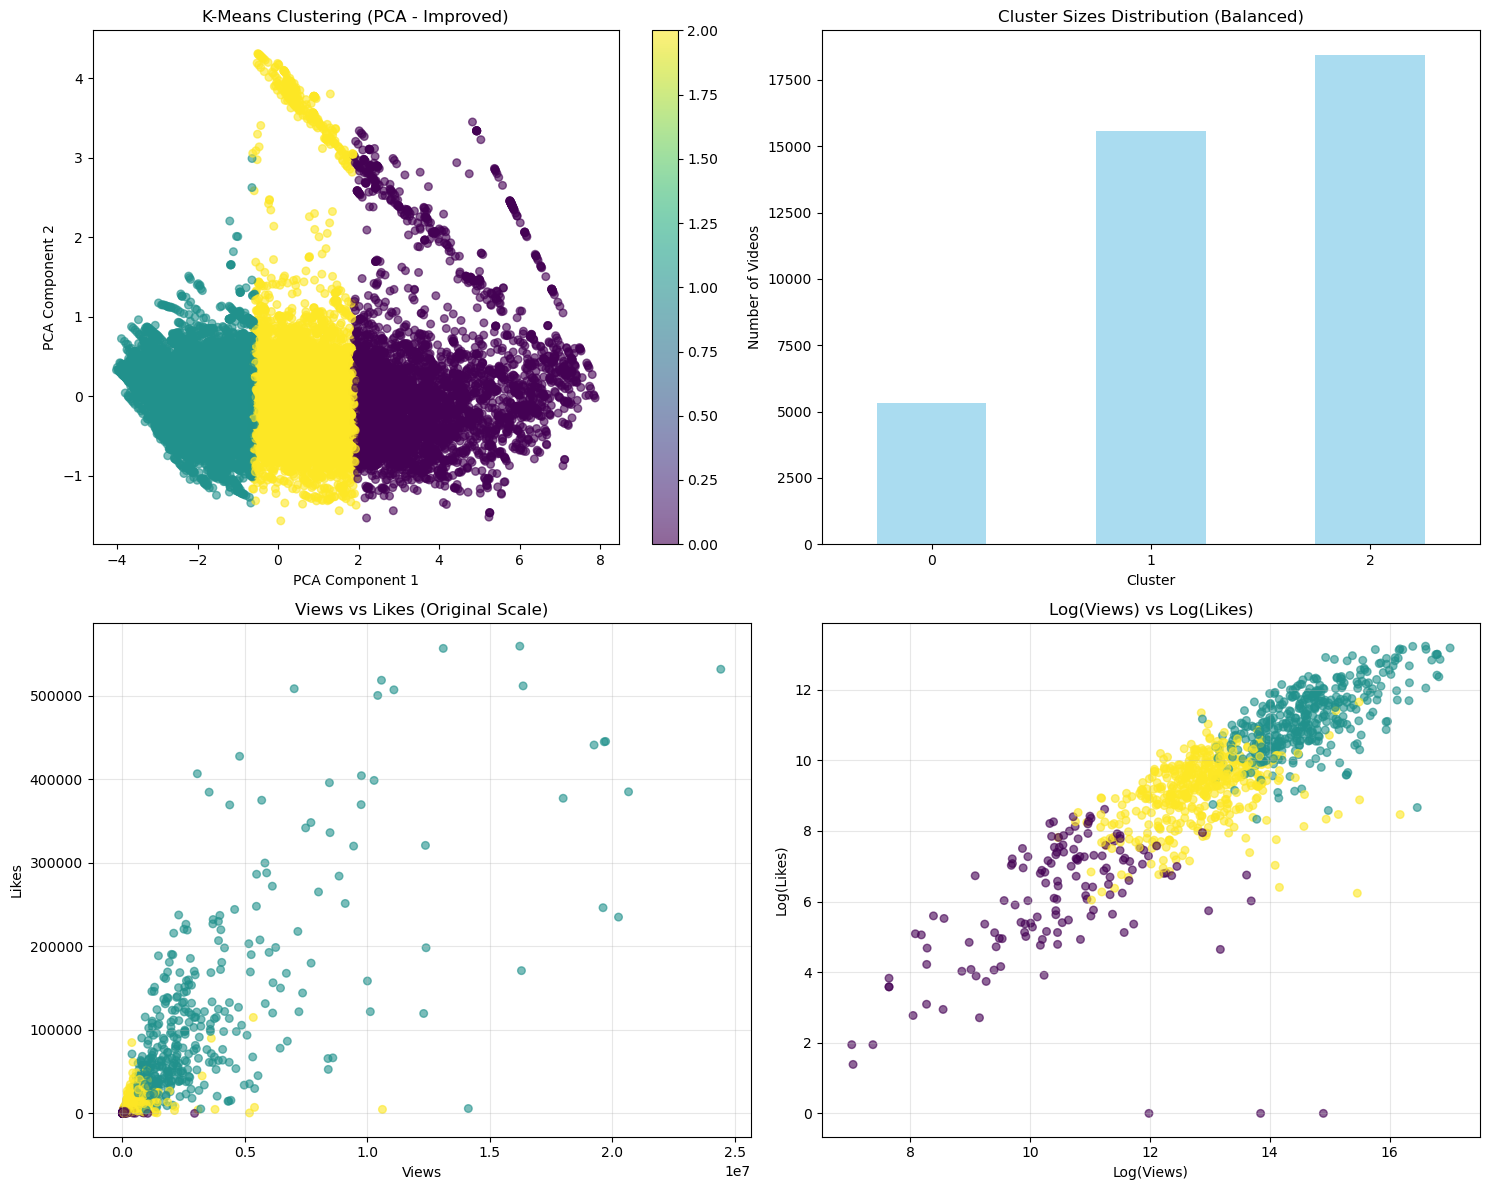

In [125]:
# IMPROVED K-MEANS CLUSTERING WITH BETTER OUTLIER HANDLING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv("C:\\Users\\rautk\\Downloads\\USvideos.csv")

# Data preprocessing for clustering
df_clean = df.dropna(subset=['views', 'likes', 'dislikes', 'comment_count'])

# Remove zeros and negative values
df_clean = df_clean[
    (df_clean['views'] > 0) & 
    (df_clean['likes'] >= 0) & 
    (df_clean['dislikes'] >= 0) & 
    (df_clean['comment_count'] >= 0)
]

#  REMOVE EXTREME OUTLIERS

print("\n🚨 HANDLING OUTLIERS:")
print("=" * 40)

# Remove top 1% outliers for each feature
for feature in ['views', 'likes', 'dislikes', 'comment_count']:
    q99 = df_clean[feature].quantile(0.99)
    before = len(df_clean)
    df_clean = df_clean[df_clean[feature] <= q99]
    after = len(df_clean)
    print(f"Removed outliers from {feature}: {before - after} videos (>{q99:,.0f})")

print(f"\nDataset after outlier removal: {len(df_clean)} videos")

# USE LOG-TRANSFORMED FEATURES FOR BETTER CLUSTERING 
# Apply log transformation to handle skewed data
df_clean['log_views'] = np.log1p(df_clean['views'])
df_clean['log_likes'] = np.log1p(df_clean['likes'])
df_clean['log_dislikes'] = np.log1p(df_clean['dislikes'])
df_clean['log_comments'] = np.log1p(df_clean['comment_count'])

# Select log-transformed features for clustering
log_features = ['log_views', 'log_likes', 'log_dislikes', 'log_comments']
X = df_clean[log_features]

print("Feature statistics after log transformation:")
print(X.describe())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# FIND OPTIMAL NUMBER OF CLUSTERS
wcss = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}: WCSS = {kmeans.inertia_:.2f}, Silhouette = {silhouette_avg:.4f}")

# Find optimal k (balance between silhouette score and practical usefulness)
optimal_k = 3  # Start with 3 for more balanced clusters
print(f"\n✅ Selected optimal clusters: {optimal_k}")

# APPLY K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_clean['cluster'] = kmeans_labels

# Calculate evaluation metrics
silhouette = silhouette_score(X_scaled, kmeans_labels)

print(f"K-Means Results:")
print(f"  Silhouette Score: {silhouette:.4f}")
print(f"  Number of Clusters: {optimal_k}")

# Cluster distribution
cluster_sizes = df_clean['cluster'].value_counts().sort_index()
print(f"\n👥 CLUSTER SIZES (IMPROVED):")
for cluster, size in cluster_sizes.items():
    percentage = (size / len(df_clean)) * 100
    print(f"  Cluster {cluster}: {size} videos ({percentage:.1f}%)")

# ANALYZE CLUSTER CHARACTERISTICS
print("\n🔍 CLUSTER ANALYSIS (ORIGINAL METRICS):")
print("=" * 40)

original_features = ['views', 'likes', 'dislikes', 'comment_count']
cluster_means = df_clean.groupby('cluster')[original_features].mean()

for cluster in range(optimal_k):
    cluster_data = df_clean[df_clean['cluster'] == cluster]
    print(f"\n📊 CLUSTER {cluster}:")
    print(f"   Size: {len(cluster_data)} videos ({(len(cluster_data)/len(df_clean)*100):.1f}%)")
    print(f"   Avg Views: {cluster_data['views'].mean():,.0f}")
    print(f"   Avg Likes: {cluster_data['likes'].mean():,.0f}")
    print(f"   Avg Dislikes: {cluster_data['dislikes'].mean():,.0f}")
    print(f"   Avg Comments: {cluster_data['comment_count'].mean():,.0f}")
    print(f"   Engagement Ratio: {(cluster_data['likes'].mean() / cluster_data['views'].mean()):.4f}")

# VISUALIZE CLUSTERS

print("\n📊 CREATING IMPROVED CLUSTER VISUALIZATIONS...")

# Use PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: PCA visualization
scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_xlabel('PCA Component 1')
axes[0, 0].set_ylabel('PCA Component 2')
axes[0, 0].set_title('K-Means Clustering (PCA - Improved)')
plt.colorbar(scatter, ax=axes[0, 0])

# Plot 2: Cluster sizes
cluster_sizes.plot(kind='bar', ax=axes[0, 1], color='skyblue', alpha=0.7)
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Videos')
axes[0, 1].set_title('Cluster Sizes Distribution (Balanced)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot 3: Views vs Likes (original scale)
sample_idx = np.random.choice(len(df_clean), size=min(1000, len(df_clean)), replace=False)
sample_data = df_clean.iloc[sample_idx]
scatter = axes[1, 0].scatter(sample_data['views'], sample_data['likes'], 
                            c=sample_data['cluster'], cmap='viridis', alpha=0.6, s=30)
axes[1, 0].set_xlabel('Views')
axes[1, 0].set_ylabel('Likes')
axes[1, 0].set_title('Views vs Likes (Original Scale)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Log Views vs Log Likes
scatter = axes[1, 1].scatter(sample_data['log_views'], sample_data['log_likes'], 
                            c=sample_data['cluster'], cmap='viridis', alpha=0.6, s=30)
axes[1, 1].set_xlabel('Log(Views)')
axes[1, 1].set_ylabel('Log(Likes)')
axes[1, 1].set_title('Log(Views) vs Log(Likes)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [126]:
#Log transform is essential for YouTube/engagement data because it converts the extreme power-law distribution into something closer to normal, 
#allowing clustering algorithms to find meaningful patterns rather than just separating outliers.

